In [1]:
# ======================================================
# LightGBM Model - Import Libraries
# ======================================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import joblib

In [2]:
# ======================================================
# Load Dataset
# ======================================================

data_path = Path("../data/processed/application_train_feature_engineered.csv")

feature_df = pd.read_csv(data_path)

print(feature_df.shape)

feature_df.head()

(307511, 249)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes,AGE_GROUP_30-40,AGE_GROUP_40-50,AGE_GROUP_50-60,AGE_GROUP_60-70,INCOME_GROUP_Low,INCOME_GROUP_Medium,INCOME_GROUP_Very High,INCOME_GROUP_Very Low
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,0,0,0,1,0,0,0,0,1,0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0,0,0,0,1,0,0,0,0,1
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0,0,0,0,1,0,1,0,0,0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,0,0,0,0,1,0,1,0,0,0


In [3]:
# ======================================================
# Features and Target
# ======================================================

X = feature_df.drop(columns=["TARGET"])

y = feature_df["TARGET"]

print(X.shape)

print(y.shape)

(307511, 248)
(307511,)


In [4]:
# ======================================================
# Train-Test Split
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(246008, 248)
(61503, 248)


In [5]:
# ======================================================
# Handle Class Imbalance
# ======================================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

11.38710976837865


In [11]:
import re

special_cols = [
    col for col in X_train.columns
    if re.search(r'[\[\]\{\}":,\\]', str(col))
]

print("Columns with special characters:")
print(special_cols)

Columns with special characters:
['NAME_TYPE_SUITE_Spouse, partner', 'ORGANIZATION_TYPE_Industry: type 1', 'ORGANIZATION_TYPE_Industry: type 10', 'ORGANIZATION_TYPE_Industry: type 11', 'ORGANIZATION_TYPE_Industry: type 12', 'ORGANIZATION_TYPE_Industry: type 13', 'ORGANIZATION_TYPE_Industry: type 2', 'ORGANIZATION_TYPE_Industry: type 3', 'ORGANIZATION_TYPE_Industry: type 4', 'ORGANIZATION_TYPE_Industry: type 5', 'ORGANIZATION_TYPE_Industry: type 6', 'ORGANIZATION_TYPE_Industry: type 7', 'ORGANIZATION_TYPE_Industry: type 8', 'ORGANIZATION_TYPE_Industry: type 9', 'ORGANIZATION_TYPE_Trade: type 1', 'ORGANIZATION_TYPE_Trade: type 2', 'ORGANIZATION_TYPE_Trade: type 3', 'ORGANIZATION_TYPE_Trade: type 4', 'ORGANIZATION_TYPE_Trade: type 5', 'ORGANIZATION_TYPE_Trade: type 6', 'ORGANIZATION_TYPE_Trade: type 7', 'ORGANIZATION_TYPE_Transport: type 1', 'ORGANIZATION_TYPE_Transport: type 2', 'ORGANIZATION_TYPE_Transport: type 3', 'ORGANIZATION_TYPE_Transport: type 4', 'WALLSMATERIAL_MODE_Stone, brick

In [12]:
import re

def clean_column_names(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)  # Replace special chars with _
        .str.replace(r'_+', '_', regex=True)             # Remove repeated underscores
        .str.strip('_')                                 # Remove leading/trailing _
    )

    return df

feature_df = clean_column_names(feature_df)

print("✅ Column names cleaned successfully!")

✅ Column names cleaned successfully!


In [13]:
import re

special_cols = [
    col for col in feature_df.columns
    if re.search(r'[\[\]\{\}":,\\]', col)
]

print(special_cols)

[]


In [14]:
X = feature_df.drop("TARGET", axis=1)
y = feature_df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
import re

def clean_column_names(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )

    return df

# Clean column names
X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)

print("✅ Column names cleaned successfully!")

✅ Column names cleaned successfully!


In [16]:
from lightgbm import LGBMClassifier

# Create LightGBM model
lgbm_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    force_col_wise=True,
    n_jobs=-1
)

# Train the model
lgbm_model.fit(X_train, y_train)

print("✅ LightGBM Model Trained Successfully!")

✅ LightGBM Model Trained Successfully!


In [17]:
# ======================================================
# Prediction
# ======================================================

y_pred = lgbm_model.predict(X_test)

y_prob = lgbm_model.predict_proba(X_test)[:,1]

In [18]:
# ======================================================
# Evaluation
# ======================================================

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

roc_auc = roc_auc_score(y_test,y_prob)

print("="*45)

print("LightGBM Performance")

print("="*45)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC  : {roc_auc:.4f}")

LightGBM Performance
Accuracy : 0.9202
Precision: 0.6627
Recall   : 0.0222
F1 Score : 0.0429
ROC AUC  : 0.7678


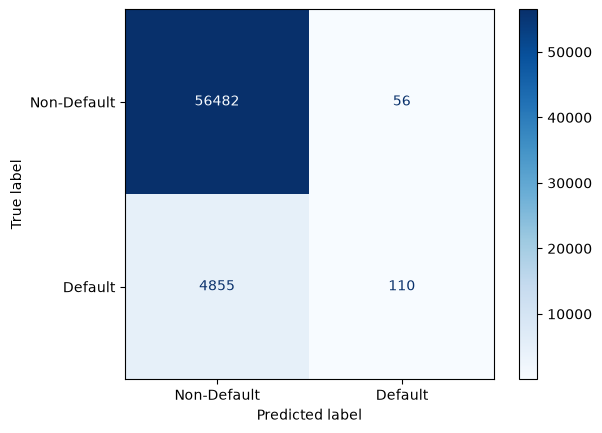

In [20]:
# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Non-Default","Default"]

)

disp.plot(cmap="Blues")

plt.show()

In [21]:
# ======================================================
# Classification Report
# ======================================================

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.66      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.79      0.51      0.50     61503
weighted avg       0.90      0.92      0.88     61503



In [22]:
# ======================================================
# Feature Importance
# ======================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":lgbm_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
112,LOAN_BURDEN,768
30,EXT_SOURCE_3,394
28,EXT_SOURCE_1,369
113,EXT_SOURCE_MEAN,332
29,EXT_SOURCE_2,293
10,DAYS_ID_PUBLISH,291
7,DAYS_BIRTH,249
5,AMT_GOODS_PRICE,228
78,DAYS_LAST_PHONE_CHANGE,219
4,AMT_ANNUITY,212


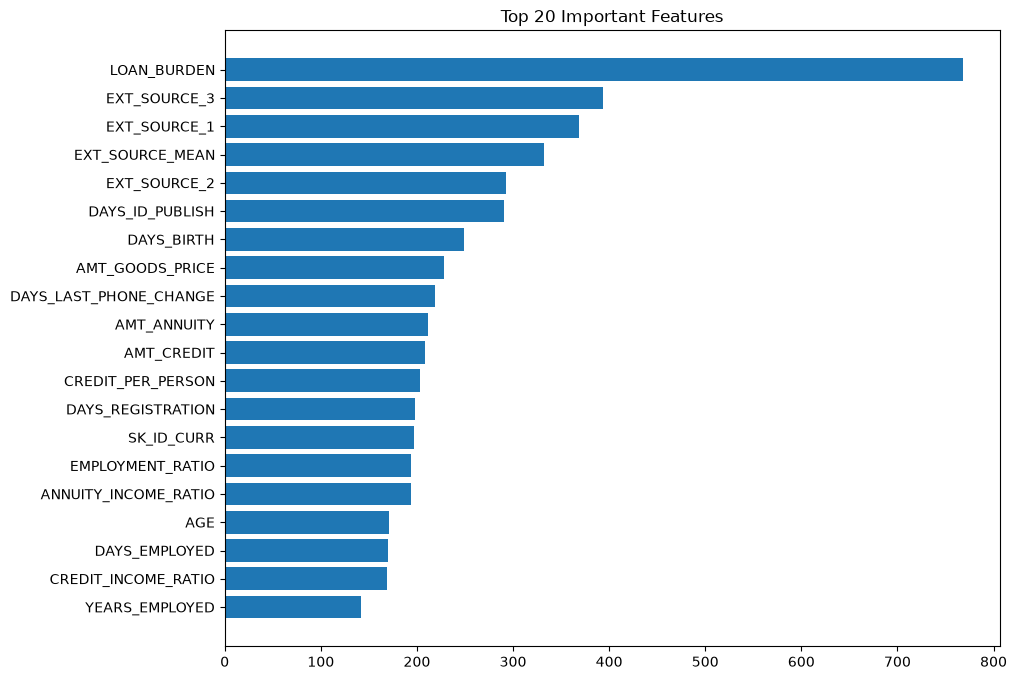

In [23]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["Importance"][:20]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [24]:
# ======================================================
# Save Model
# ======================================================

model_path = Path("../models")

model_path.mkdir(

    parents=True,

    exist_ok=True

)

joblib.dump(

    lgbm_model,

    model_path/"lightgbm_model.pkl"

)

print("LightGBM Model Saved Successfully!")

LightGBM Model Saved Successfully!


In [25]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    force_col_wise=True,
    class_weight="balanced",
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

,max_depth,8
,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,class_weight,'balanced'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,force_col_wise,True
,boosting_type,'gbdt'


In [28]:
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("="*50)
print("LightGBM Performance")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

LightGBM Performance
Accuracy : 0.7216
Precision: 0.1771
Recall   : 0.6717
F1 Score : 0.2803
ROC AUC  : 0.7684


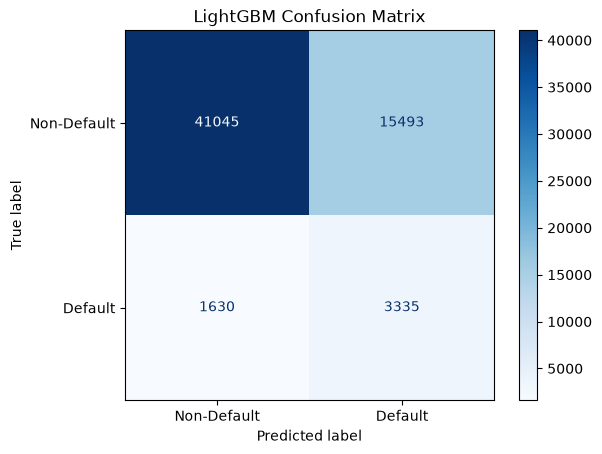

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

# Plot
disp.plot(cmap="Blues", values_format="d")

plt.title("LightGBM Confusion Matrix")
plt.show()

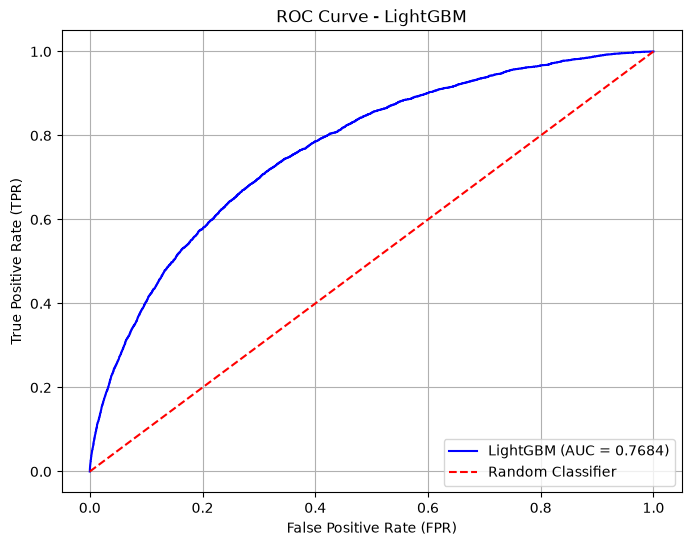

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities for the positive class
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color="blue",
         label=f"LightGBM (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1],
         linestyle="--",
         color="red",
         label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - LightGBM")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [32]:
# Save Model
# ============================================

model_path = Path("../models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(
    lgbm_model,
    model_path / "lightgbm_model.pkl"
)

print("✅ LightGBM Model Saved Successfully!")


✅ LightGBM Model Saved Successfully!


In [33]:
# ============================================
# Save Feature Names
# ============================================

joblib.dump(
    X_train.columns.tolist(),
    model_path / "lightgbm_feature_names.pkl"
)

print("✅ Feature Names Saved Successfully!")

✅ Feature Names Saved Successfully!
